In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

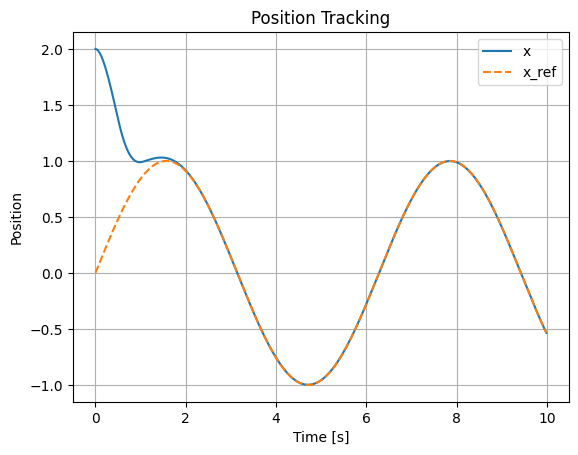

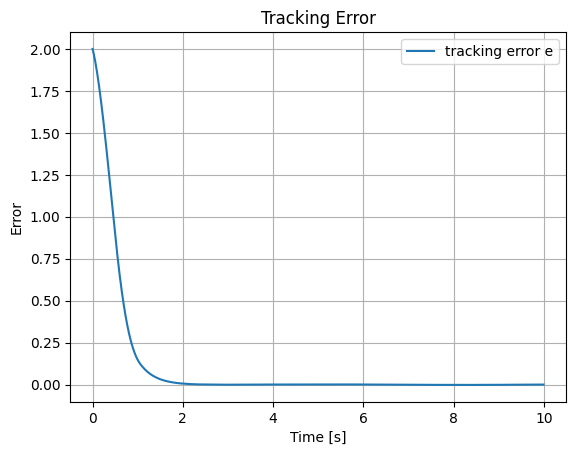

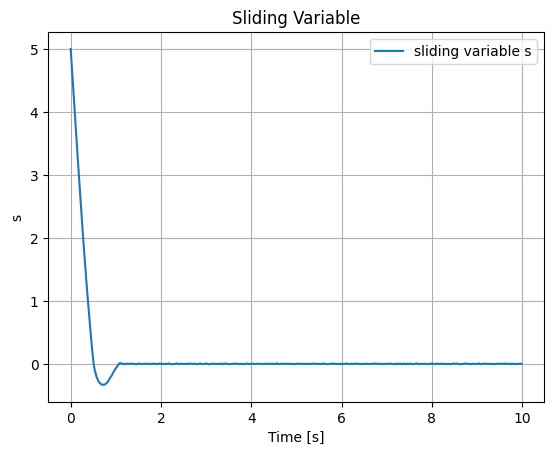

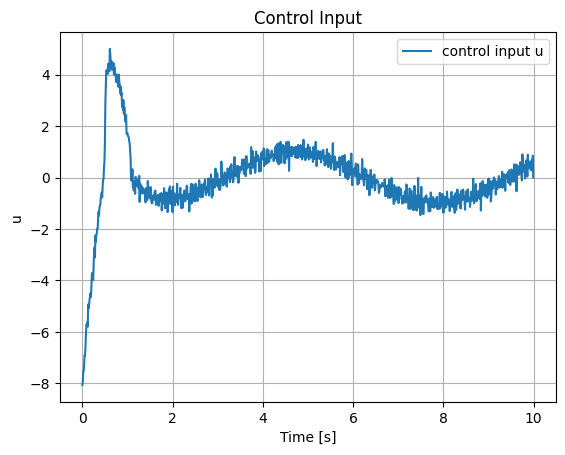

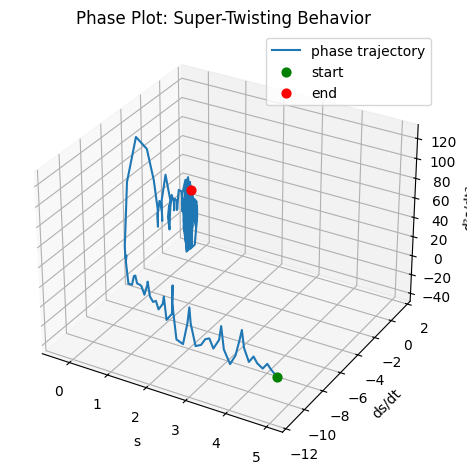

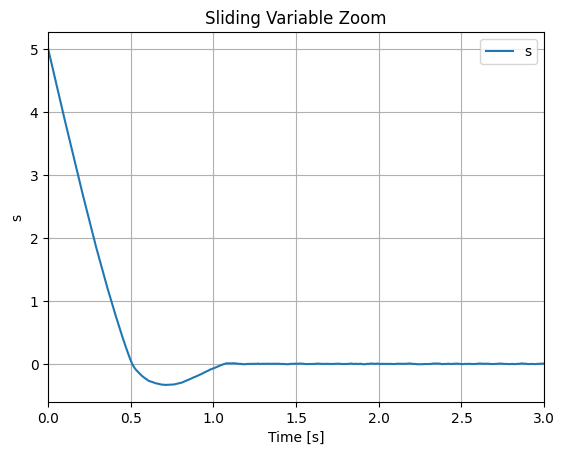

In [2]:
dt = 0.01
T = 10.0
t = np.arange(0, T, dt)

# Controller gains
lam = 3.0
k1 = 5.0
k2 = 10.0
eps = 0.01

def sat(x, eps):
    return np.clip(x / eps, -1.0, 1.0)

# Reference trajectory
def x_ref(t):
    return np.sin(t)

def dx_ref(t):
    return np.cos(t)

def ddx_ref(t):
    return -np.sin(t)

# States
x = np.zeros_like(t)
dx = np.zeros_like(t)

# Initial conditions
x[0] = 2.0
dx[0] = 0.0

s_arr = np.zeros_like(t)
u_arr = np.zeros_like(t)

nu = 0.0  # internal Super-Twisting-State

noise_std = 0.2
noise = np.random.normal(0.0, noise_std, size=t.shape)

# Simulation
for i in range(len(t) - 1):
    e = x[i] - x_ref(t[i])
    de = dx[i] - dx_ref(t[i])

    s = de + lam * e
    sigma = sat(s, eps)

    nu = nu - k2 * sigma * dt

    u_sta = -k1 * np.sqrt(abs(s)) * sigma + nu
    u = ddx_ref(t[i]) + noise[i] - lam * de + u_sta

    dx[i + 1] = dx[i] + u * dt
    x[i + 1] = x[i] + dx[i + 1] * dt

    s_arr[i] = s
    u_arr[i] = u


e = x[-1] - x_ref(t[-1])
de = dx[-1] - dx_ref(t[-1])
s_arr[-1] = de + lam * e
    # ---------- Plot ----------
plt.figure()
plt.plot(t, x, label="x")
plt.plot(t, x_ref(t), "--", label="x_ref")
plt.xlabel("Time [s]")
plt.ylabel("Position")
plt.title("Position Tracking")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, x - x_ref(t), label="tracking error e")
plt.xlabel("Time [s]")
plt.ylabel("Error")
plt.title("Tracking Error")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, s_arr, label="sliding variable s")
plt.xlabel("Time [s]")
plt.ylabel("s")
plt.title("Sliding Variable")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, u_arr, label="control input u")
plt.xlabel("Time [s]")
plt.ylabel("u")
plt.title("Control Input")
plt.grid(True)
plt.legend()
plt.show()

# ---------- Phase Plot: Twisting / Super-Twisting behavior ----------
ds_arr = np.gradient(s_arr, dt)
dds_arr = np.gradient(ds_arr, dt)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot(s_arr, ds_arr, dds_arr, label="phase trajectory", lw=1.5)
ax.scatter(s_arr[0], ds_arr[0], dds_arr[0], color="green", s=40, label="start")
ax.scatter(s_arr[-1], ds_arr[-1], dds_arr[-1], color="red", s=40, label="end")

ax.set_xlabel("s")
ax.set_ylabel("ds/dt")
ax.set_zlabel("d²s/dt²")
ax.set_title("Phase Plot: Super-Twisting Behavior")
ax.legend()
plt.tight_layout()
plt.show()

# ---------- Zoom near sliding surface ----------
plt.figure()
plt.plot(t, s_arr, label="s")
plt.xlabel("Time [s]")
plt.ylabel("s")
plt.title("Sliding Variable Zoom")
plt.xlim(0, 3)
plt.grid(True)
plt.legend()
plt.show()

In [3]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
fig = go.Figure(data=[go.Scatter3d(x=s_arr, y=ds_arr, z=dds_arr, mode="lines", name="phase trajectory")])
fig.add_trace(go.Scatter3d(x=[s_arr[0]], y=[ds_arr[0]], z=[dds_arr[0]], mode="markers", marker=dict(size=5, color="green"), name="start"))
fig.add_trace(go.Scatter3d(x=[s_arr[-1]], y=[ds_arr[-1]], z=[dds_arr[-1]], mode="markers", marker=dict(size=5, color="red"), name="end"))
fig.update_layout(scene=dict(xaxis_title="s", yaxis_title="ds/dt", zaxis_title="d²s/dt²"), title="Phase Plot: Super-Twisting Behavior")
fig.show()

In [ ]:
from Models.diffdrive import DiffDrive

class SuperTwistingController:
    def __init__(self, lam=3.0, k1=5.0, k2=10.0, eps=0.01):
        self.lam = lam
        self.k1 = k1
        self.k2 = k2
        self.eps = eps
        self.nu = 0.0  # internal Super-Twisting-State
        self.prev_state = np.zeros(3)  # [x, y, phi]
        self.prev_waypoint = np.zeros(2)  # [x_ref, y_ref]

    def sat(self, x):
        return np.clip(x / self.eps, -1.0, 1.0)
    
    def wrap_angle(self, angle):
        return (angle + np.pi) % (2 * np.pi) - np.pi

    def compute_control(self, x, y, phi, waypoint, dt):
        
        phi_des = np.arctan2(waypoint[1] - y, waypoint[0] - x)
        e = self.wrap_angle(phi - phi_des)

        s = e
        sigma = self.sat(s)

        self.nu -= self.k2 * sigma * dt

        u_sta = -self.k1 * np.sqrt(abs(s)) * sigma + self.nu
        u = self.prev_state[2] - self.lam * de + u_sta
        
        #e_prev = e
        de = (phi - self.prev_state[2]) / dt
        self.prev_state = np.array([x, y, phi]) / dt
        self.prev_waypoint = waypoint

        return u